In [1]:
# Importando livrarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

sns.set_theme(style='whitegrid')
np.random.seed(42)

In [23]:
# carrega base de dados
df = pd.read_csv("/Users/claudiojacomassi/Documents/GitHub/Exercicio Aula Aprendizado de Máquina Não Supervisionado 1/vinhos_dataset.csv")
df['color'] = df['color'].map({'red': 0, 'white': 1})

In [24]:
# Verificando a distribuição dos perfis simulados
df['color'].value_counts()

color
1    4898
0    1599
Name: count, dtype: int64

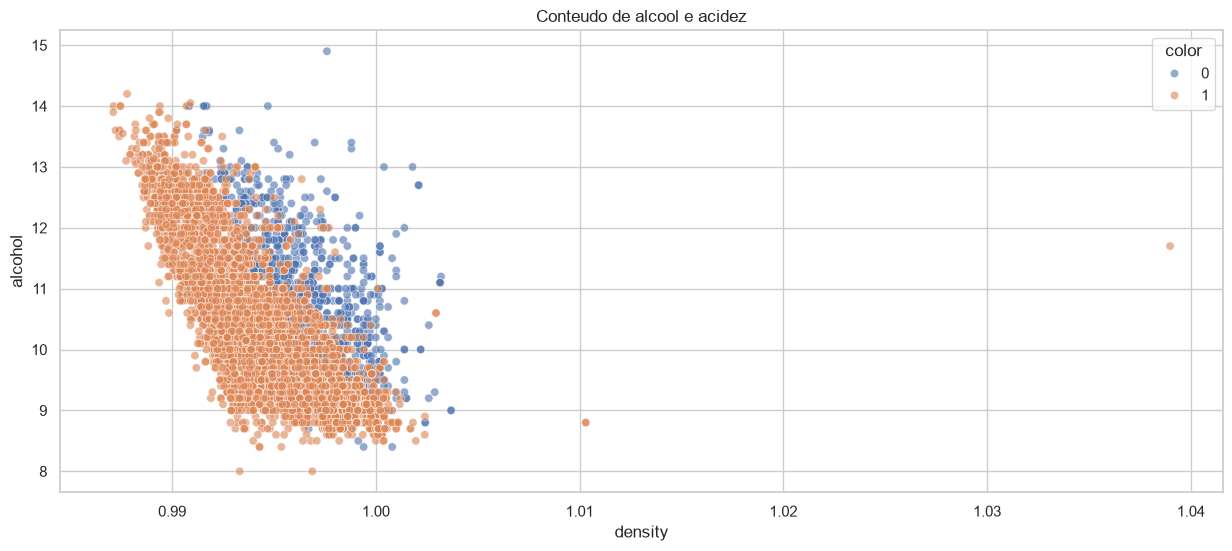

In [29]:
# Grafico conteudo de alcool vs acidez
plt.figure(figsize=(15, 6))
sns.scatterplot(
    data=df,
    x='density',
    y='alcohol',
    hue='color',
    alpha=0.6
)
plt.title('Conteudo de alcool e acidez')
plt
plt.show()

In [30]:

# Definindo os features e mostrando o cabecario e 5 linhas
features = ['fixed_acidity',
    'volatile_acidity',
    'citric_acid',
    'residual_sugar',
    'chlorides',
    'free_sulfur_dioxide',
    'total_sulfur_dioxide',
    'density',
    'pH',
    'sulphates',
    'alcohol', 'color' , 'quality']
X = df[features].copy()
X.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,color,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,0,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0,5


In [31]:
# Faz o scaler dos "features" usando o standardscaler 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[:5]

array([[ 0.14247327,  2.18883292, -2.19283252, -0.7447781 ,  0.56995782,
        -1.10013986, -1.44635852,  1.03499282,  1.81308951,  0.19309677,
        -0.91546416, -1.75018984, -0.93722961],
       [ 0.45103572,  3.28223494, -2.19283252, -0.59764007,  1.1979747 ,
        -0.31132009, -0.86246863,  0.70148631, -0.11507303,  0.99957862,
        -0.58006813, -1.75018984, -0.93722961],
       [ 0.45103572,  2.55330026, -1.91755268, -0.66069923,  1.02669737,
        -0.87476278, -1.09248586,  0.76818761,  0.25811972,  0.79795816,
        -0.58006813, -1.75018984, -0.93722961],
       [ 3.07381662, -0.36243847,  1.66108525, -0.7447781 ,  0.54141159,
        -0.76207424, -0.98632406,  1.10169412, -0.3638682 ,  0.32751041,
        -0.58006813, -1.75018984,  0.20799905],
       [ 0.14247327,  2.18883292, -2.19283252, -0.7447781 ,  0.56995782,
        -1.10013986, -1.44635852,  1.03499282,  1.81308951,  0.19309677,
        -0.91546416, -1.75018984, -0.93722961]])

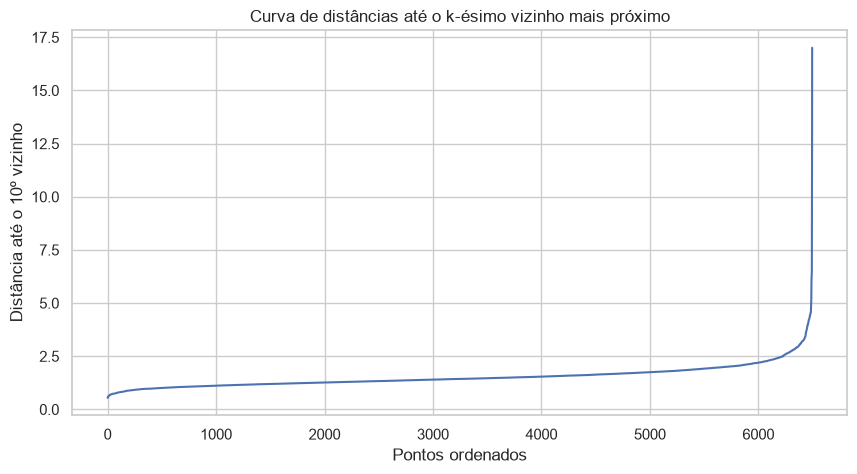

In [32]:
# Apoio para escolha de `eps` com gráfico de distâncias
min_samples = 10

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

distancias_k = np.sort(distances[:, min_samples - 1])

plt.figure(figsize=(10, 5))
plt.plot(distancias_k)
plt.title('Curva de distâncias até o k-ésimo vizinho mais próximo')
plt.xlabel('Pontos ordenados')
plt.ylabel(f'Distância até o {min_samples}º vizinho')
plt.show()

In [33]:
eps_escolhido = 2
dbscan = DBSCAN(eps=eps_escolhido, min_samples=min_samples)
clusters = dbscan.fit_predict(X_scaled)

In [34]:
df['cluster'] = clusters
df.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,color,cluster
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0,0


In [35]:
df['cluster'].value_counts().sort_index()

cluster
-1     334
 0    1432
 1    4731
Name: count, dtype: int64